In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 1. Dataset Preparation & Vocabulary Setup
sample_text = "machine learning and deep learning with long short term memory networks"

# Create vocabulary mapping
chars = sorted(list(set(sample_text)))
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for i, ch in enumerate(chars)}
vocab_size = len(chars)

seq_length = 4  # Window size for input sequences

class CharDataset(Dataset):
    def __init__(self, text, seq_length, char2idx):
        self.x_data = []
        self.y_data = []
        for i in range(len(text) - seq_length):
            seq_in = text[i:i + seq_length]
            seq_out = text[i + seq_length]
            self.x_data.append([char2idx[ch] for ch in seq_in])
            self.y_data.append(char2idx[seq_out])
            
    def __len__(self):
        return len(self.x_data)
    
    def __getitem__(self, idx):
        return torch.tensor(self.x_data[idx], dtype=torch.long), torch.tensor(self.y_data[idx], dtype=torch.long)

dataset = CharDataset(sample_text, seq_length, char2idx)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# 2. Model Architecture
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(CharLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        out = self.embedding(x)          # [batch, seq_len, embed_dim]
        out, _ = self.lstm(out)           # [batch, seq_len, hidden_dim]
        out = self.fc(out[:, -1, :])      # Last time step output
        return out

embed_dim = 16
hidden_dim = 64
model = CharLSTM(vocab_size, embed_dim, hidden_dim)

# 3. Model Training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("Training Character-Level LSTM model...")
model.train()
for epoch in range(150):
    total_loss = 0
    for x_batch, y_batch in dataloader:
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

print("Training Complete!\n" + "=" * 50)

# 4. Prediction Logic for Dynamic Input
def predict_next_char(model, input_str, seq_length, char2idx, idx2char):
    model.eval()
    
    # Check if input meets sequence length requirements
    if len(input_str) < seq_length:
        print(f"Error: Input string must be at least {seq_length} characters long.")
        return None
    
    # Extract the last `seq_length` characters
    sub_str = input_str[-seq_length:]
    
    # Check for unseen characters outside vocabulary
    unseen = [ch for ch in sub_str if ch not in char2idx]
    if unseen:
        print(f"Error: Character(s) '{unseen}' not found in training vocabulary.")
        return None
    
    encoded = [char2idx[ch] for ch in sub_str]
    input_tensor = torch.tensor([encoded], dtype=torch.long)
    
    with torch.no_grad():
        out = model(input_tensor)
        predicted_idx = torch.argmax(out, dim=1).item()
        
    return idx2char[predicted_idx]

# 5. Interactive User Input Loop
print(f"Available Vocabulary: '{''.join(chars)}'")
print(f"Enter a sequence of at least {seq_length} characters (or type 'exit' to quit).\n")

while True:
    user_input = input("Enter input sequence: ")
    
    if user_input.lower() == 'exit':
        print("Exiting interactive prompt.")
        break
        
    next_char = predict_next_char(model, user_input, seq_length, char2idx, idx2char)
    
    if next_char is not None:
        print(f"Input: '{user_input}' -> Predicted Next Char: '{next_char}'")
        print(f"Full Result: '{user_input}{next_char}'")
    print("-" * 50)

Training Character-Level LSTM model...
Training Complete!
Available Vocabulary: ' acdeghiklmnoprstwy'
Enter a sequence of at least 4 characters (or type 'exit' to quit).



Enter input sequence:  lear


Input: 'lear' -> Predicted Next Char: 'n'
Full Result: 'learn'
--------------------------------------------------


Enter input sequence:  exit


Exiting interactive prompt.


Loading dataset: /kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv
Using column 'T (degC)' with 1000 samples.
Training lightweight model...


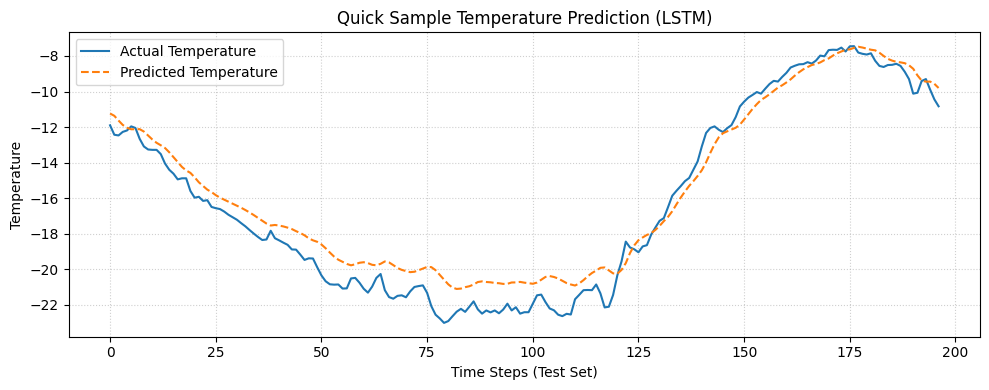

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# 1. Load Sample of Dataset
input_dir = "/kaggle/input"
csv_files = glob.glob(os.path.join(input_dir, "**", "*.csv"), recursive=True)

if not csv_files:
    raise FileNotFoundError("No CSV file found in /kaggle/input. Please attach a dataset.")

dataset_path = csv_files[0]
print(f"Loading dataset: {dataset_path}")

# Load ONLY the first 1,000 rows for high-speed execution
df = pd.read_csv(dataset_path, nrows=1000)

temp_col_candidates = ['meantemp', 'T (degC)', 'temp', 'Temperature', 'temperature']
temp_col = None

for col in temp_col_candidates:
    if col in df.columns:
        temp_col = col
        break

if temp_col is None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    temp_col = numeric_cols[0]

print(f"Using column '{temp_col}' with {len(df)} samples.")
temperatures = df[temp_col].dropna().values.astype(np.float32)

# 2. Normalization & Sequence Creation
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_temps = scaler.fit_transform(temperatures.reshape(-1, 1))

window_size = 15  # Small lookback window

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_temps, window_size)

# Train/Test Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)

# 3. Lightweight LSTM Architecture
class FastLSTM(nn.Module):
    def __init__(self):
        super(FastLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, num_layers=1, batch_first=True)
        self.fc = nn.Linear(32, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model_ts = FastLSTM()
criterion = nn.MSELoss()
optimizer = optim.Adam(model_ts.parameters(), lr=0.01)

# 4. Fast Training Loop (10 Epochs)
epochs = 10
print("Training lightweight model...")
model_ts.train()
for epoch in range(epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_ts(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

# 5. Evaluation and Plotting
model_ts.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    test_preds_scaled = model_ts(X_test_tensor).numpy()

y_test_actual = scaler.inverse_transform(y_test)
y_test_predicted = scaler.inverse_transform(test_preds_scaled)

plt.figure(figsize=(10, 4))
plt.plot(y_test_actual, label="Actual Temperature", color="tab:blue", linewidth=1.5)
plt.plot(y_test_predicted, label="Predicted Temperature", color="tab:orange", linestyle="--", linewidth=1.5)
plt.title("Quick Sample Temperature Prediction (LSTM)")
plt.xlabel("Time Steps (Test Set)")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()